In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
kl_error_svd = torch.load("state_spectrum_sweep/experiments/suite_kl_20260322_064037/prompt_02_kl.pt")
mse_error_svd = torch.load("state_spectrum_sweep/experiments/suite_kl_20260322_064037/prompt_02_mse.pt")
cosine_similarity_svd = torch.load("state_spectrum_sweep/experiments/suite_kl_20260322_064037/prompt_02_cosine_similarity.pt")
relative_frob_svd = torch.load("state_spectrum_sweep/experiments/suite_kl_20260322_064037/prompt_02_rel_frob.pt")
retained_energy_svd = torch.load("state_spectrum_sweep/experiments/suite_kl_20260322_064037/prompt_02_retained_energy.pt")

kl_error_q = torch.load("state_spectrum_sweep/experiments/suite_quant_20260323_233235/prompt_02_kl.pt")
mse_error_q = torch.load("state_spectrum_sweep/experiments/suite_quant_20260323_233235/prompt_02_mse.pt")
cosine_similarity_q = torch.load("state_spectrum_sweep/experiments/suite_quant_20260323_233235/prompt_02_cosine_similarity.pt")
relative_frob_q = torch.load("state_spectrum_sweep/experiments/suite_quant_20260323_233235/prompt_02_rel_frob.pt")
retained_energy_q = torch.load("state_spectrum_sweep/experiments/suite_quant_20260323_233235/prompt_02_retained_energy.pt")

: 

In [65]:
mse_error_means_svd = torch.mean(mse_error_svd, dim=1)
mse_error_means_q = torch.mean(mse_error_q, dim=1)

In [66]:
y_svd = torch.log1p(kl_error_svd.float())
y_q = torch.log1p(kl_error_q.float())

rf_mean_svd = relative_frob_svd.mean(dim=1)
rf_max_svd = relative_frob_svd.max(dim=1).values
rf_tail_svd = relative_frob_svd[:, -4:].mean(dim=1)
mse_mean_svd = mse_error_svd.mean(dim=1)
mse_max_svd = mse_error_svd.max(dim=1).values

rf_mean_q = relative_frob_q.mean(dim=1)
rf_max_q = relative_frob_q.max(dim=1).values
rf_tail_q = relative_frob_q[:, -4:].mean(dim=1)
mse_mean_q = mse_error_q.mean(dim=1)
mse_max_q = mse_error_q.max(dim=1).values

In [67]:
kl_svd = kl_error_svd.float().cpu()
mse_svd = mse_error_svd.float().cpu()
rf_svd = relative_frob_svd.float().cpu()
cos_svd = cosine_similarity_svd.float().cpu()
re_svd = retained_energy_svd.float().cpu()
steps_svd = np.arange(len(kl_svd))
# Helpful KL transform for visualization if spikes are large
log_kl_svd = torch.log1p(kl_svd)
# Per-step aggregates
rf_mean_svd = rf_svd.mean(dim=1)
rf_max_svd = rf_svd.max(dim=1).values
rf_tail_svd = rf_svd[:, -4:].mean(dim=1)   # last 4 layers
mse_mean_svd = mse_svd.mean(dim=1)
mse_max_svd = mse_svd.max(dim=1).values
re_mean_svd = re_svd.mean(dim=1)
re_min_svd = re_svd.min(dim=1).values
cos_mean_svd = cos_svd.mean(dim=1)
cos_min_svd = cos_svd.min(dim=1).values
# High-KL mask: top 10% of steps
high_mask_svd = kl_svd >= torch.quantile(kl_svd, 0.9)
print("num high-KL steps:", int(high_mask_svd.sum()))
print("high-KL step indices:", torch.where(high_mask_svd)[0].tolist())

kl_q = kl_error_q.float().cpu()
mse_q = mse_error_q.float().cpu()
rf_q = relative_frob_q.float().cpu()
cos_q = cosine_similarity_q.float().cpu()
re_q = retained_energy_q.float().cpu()
steps_q = np.arange(len(kl_q))
# Helpful KL transform for visualization if spikes are large
log_kl_q = torch.log1p(kl_q)
# Per-step aggregates
rf_mean_q = rf_q.mean(dim=1)
rf_max_q = rf_q.max(dim=1).values
rf_tail_q = rf_q[:, -4:].mean(dim=1)   # last 4 layers
mse_mean_q = mse_q.mean(dim=1)
mse_max_q = mse_q.max(dim=1).values
re_mean_q = re_q.mean(dim=1)
re_min_q = re_q.min(dim=1).values
cos_mean_q = cos_q.mean(dim=1)
cos_min_q = cos_q.min(dim=1).values
# High-KL mask: top 10% of steps
high_mask_q = kl_q >= torch.quantile(kl_q, 0.9)
print("num high-KL steps:", int(high_mask_q.sum()))
print("high-KL step indices:", torch.where(high_mask_q)[0].tolist())

num high-KL steps: 20
high-KL step indices: [0, 15, 24, 31, 33, 58, 61, 64, 67, 94, 108, 125, 127, 129, 130, 136, 140, 146, 148, 156]
num high-KL steps: 20
high-KL step indices: [0, 3, 6, 24, 31, 33, 49, 64, 70, 94, 108, 118, 125, 127, 129, 130, 140, 146, 148, 156]


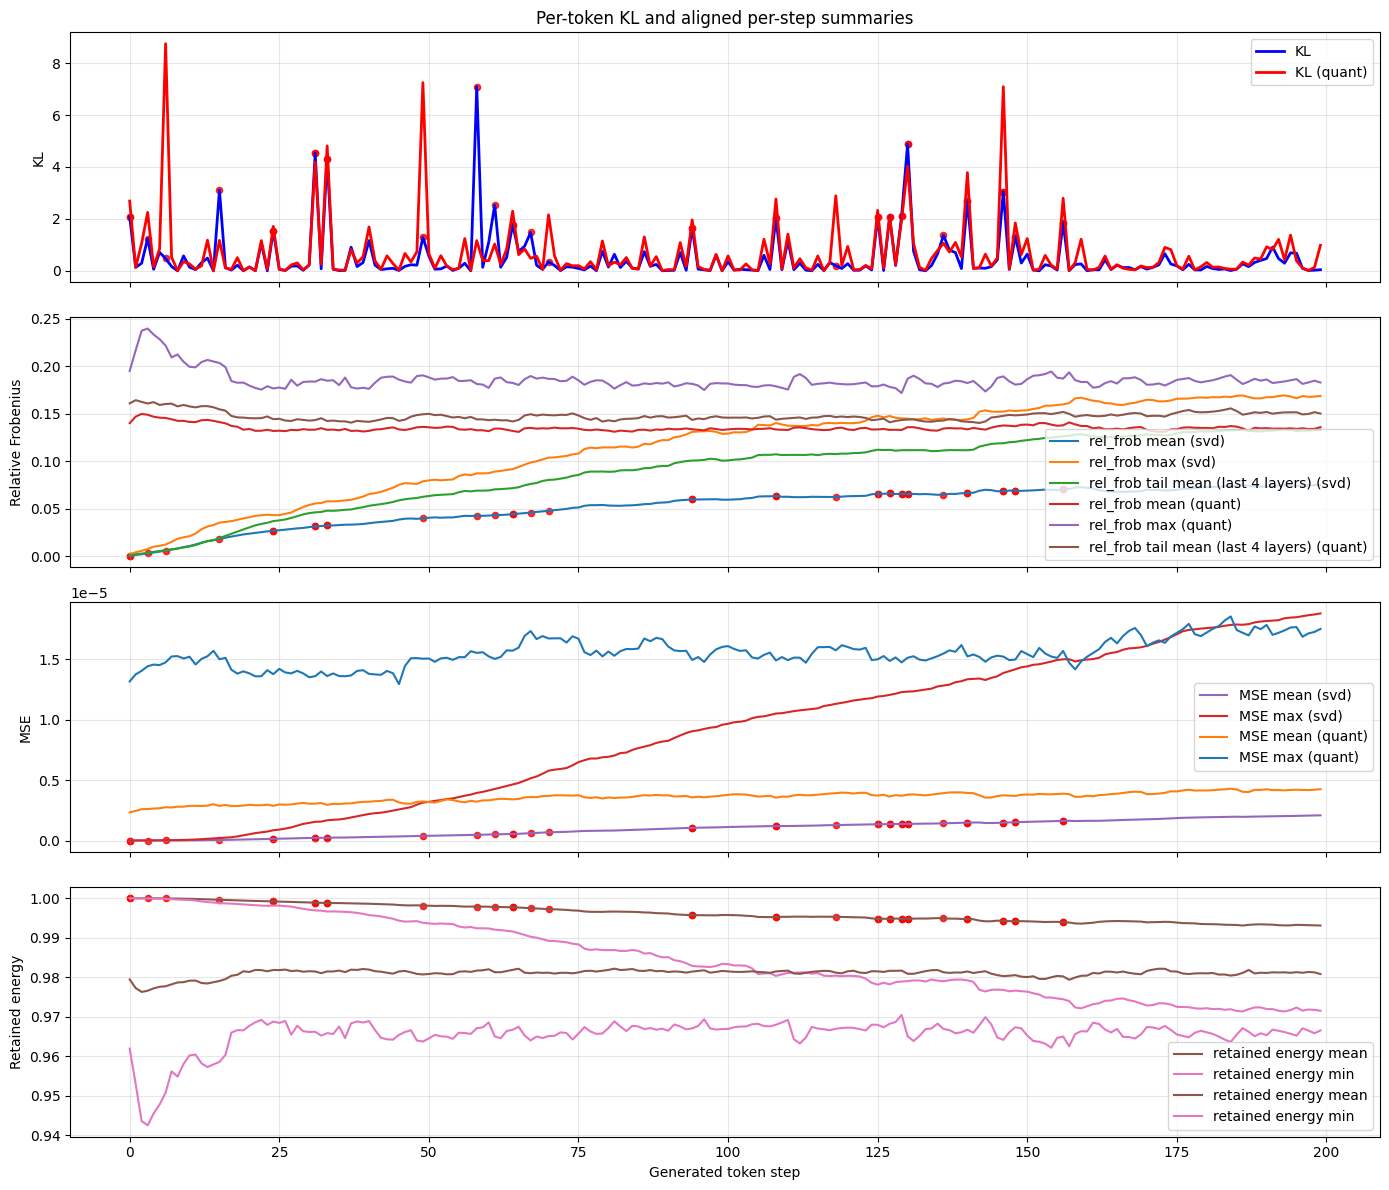

In [68]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
axes[0].plot(steps_svd, kl_svd.numpy(), label="KL", color="blue", linewidth=2)
# axes[0].plot(steps_svd, log_kl_svd.numpy(), label="log1p(KL)", color="tab:gray", linestyle="--")
axes[0].plot(steps_q, kl_q.numpy(), label="KL (quant)", color="red", linewidth=2)
# axes[0].plot(steps_q, log_kl_q.numpy(), label="log1p(KL) (quant)", color="tab:gray", linestyle="--")

axes[0].set_ylabel("KL")
axes[0].set_title("Per-token KL and aligned per-step summaries")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(steps_svd, rf_mean_svd.numpy(), label="rel_frob mean (svd)", color="tab:blue")
axes[1].plot(steps_svd, rf_max_svd.numpy(), label="rel_frob max (svd)", color="tab:orange")
axes[1].plot(steps_svd, rf_tail_svd.numpy(), label="rel_frob tail mean (last 4 layers) (svd)", color="tab:green")
axes[1].plot(steps_q, rf_mean_q.numpy(), label="rel_frob mean (quant)", color="tab:red")
axes[1].plot(steps_q, rf_max_q.numpy(), label="rel_frob max (quant)", color="tab:purple")
axes[1].plot(steps_q, rf_tail_q.numpy(), label="rel_frob tail mean (last 4 layers) (quant)", color="tab:brown")
axes[1].set_ylabel("Relative Frobenius")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[2].plot(steps_svd, mse_mean_svd.numpy(), label="MSE mean (svd)", color="tab:purple")
axes[2].plot(steps_svd, mse_max_svd.numpy(), label="MSE max (svd)", color="tab:red")
axes[2].plot(steps_q, mse_mean_q.numpy(), label="MSE mean (quant)", color="tab:orange")
axes[2].plot(steps_q, mse_max_q.numpy(), label="MSE max (quant)", color="tab:blue")
axes[2].set_ylabel("MSE")
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[3].plot(steps_svd, re_mean_svd.numpy(), label="retained energy mean", color="tab:brown")
axes[3].plot(steps_svd, re_min_svd.numpy(), label="retained energy min", color="tab:pink")
axes[3].plot(steps_q, re_mean_q.numpy(), label="retained energy mean", color="tab:brown")
axes[3].plot(steps_q, re_min_q.numpy(), label="retained energy min", color="tab:pink")
axes[3].set_ylabel("Retained energy")
axes[3].set_xlabel("Generated token step")
axes[3].legend()
axes[3].grid(alpha=0.3)
for ax in axes:
    high_steps = steps_svd[high_mask_svd.numpy()]
    if len(high_steps) > 0:
        ax.scatter(high_steps, ax.get_lines()[0].get_ydata()[high_mask_svd.numpy()],
                   color="red", s=20, alpha=0.8)
    high_steps = steps_q[high_mask_q.numpy()]
    if len(high_steps) > 0:
        ax.scatter(high_steps, ax.get_lines()[0].get_ydata()[high_mask_q.numpy()],
                   color="red", s=20, alpha=0.8)
plt.tight_layout()
plt.show()

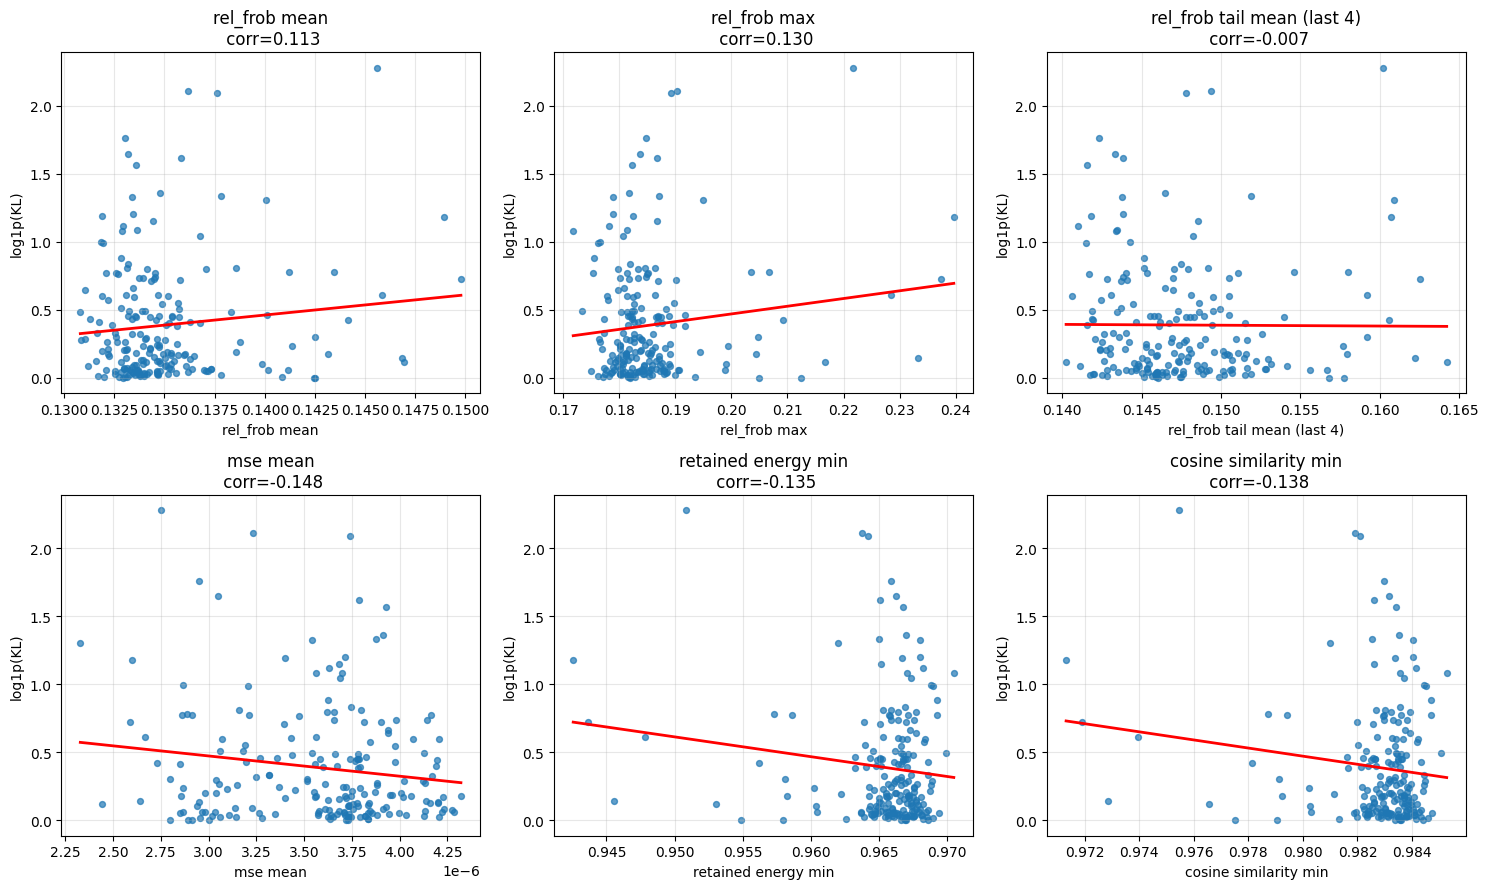

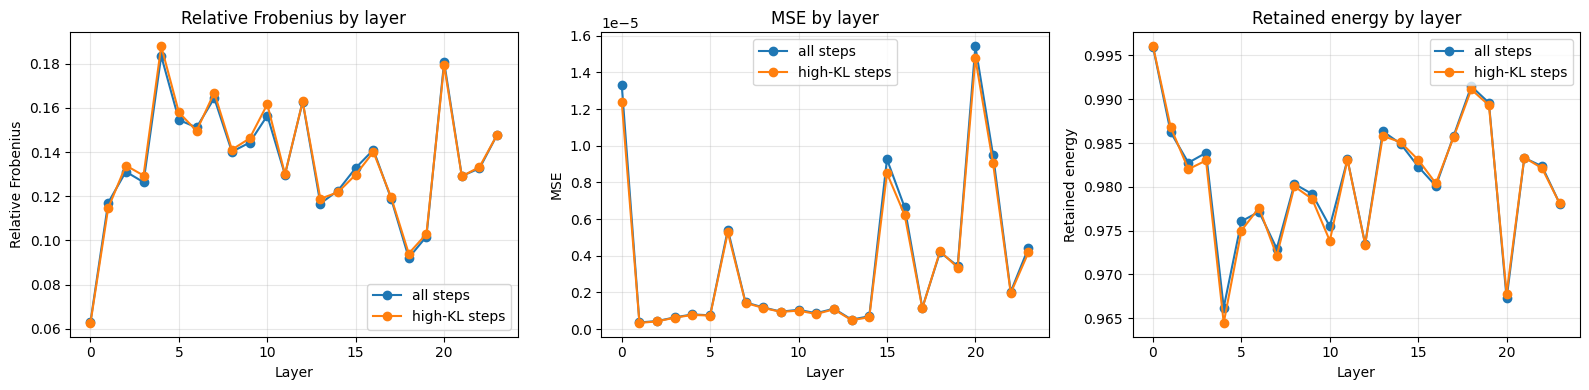

In [46]:
layers = np.arange(rf.shape[1])
rf_base = rf.mean(dim=0)
rf_high = rf[high_mask].mean(dim=0)
mse_base = mse.mean(dim=0)
mse_high = mse[high_mask].mean(dim=0)
re_base = re.mean(dim=0)
re_high = re[high_mask].mean(dim=0)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(layers, rf_base.numpy(), marker="o", label="all steps")
axes[0].plot(layers, rf_high.numpy(), marker="o", label="high-KL steps")
axes[0].set_title("Relative Frobenius by layer")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Relative Frobenius")
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[1].plot(layers, mse_base.numpy(), marker="o", label="all steps")
axes[1].plot(layers, mse_high.numpy(), marker="o", label="high-KL steps")
axes[1].set_title("MSE by layer")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("MSE")
axes[1].grid(alpha=0.3)
axes[1].legend()
axes[2].plot(layers, re_base.numpy(), marker="o", label="all steps")
axes[2].plot(layers, re_high.numpy(), marker="o", label="high-KL steps")
axes[2].set_title("Retained energy by layer")
axes[2].set_xlabel("Layer")
axes[2].set_ylabel("Retained energy")
axes[2].grid(alpha=0.3)
axes[2].legend()
plt.tight_layout()
plt.show()

In [4]:
import os

# prompt level KL statistics
def load_kl_stats(path: str):
    kl_tensors = []
    for file in os.listdir(path):
        if file.endswith(".pt") and "kl" in file:
            kl_stats = torch.load(os.path.join(path, file))
            kl_stats = kl_stats.float().cpu().numpy()
            kl_tensors.append(kl_stats)

    return kl_tensors

In [11]:
kl_tensors_svd = load_kl_stats("state_spectrum_sweep/experiments/suite_kl_parallel_20260416_063354")
kl_tensors_q_4 = load_kl_stats("state_spectrum_sweep/experiments/suite_quant_20260323_4bit")
kl_tensors_q_8 = load_kl_stats("state_spectrum_sweep/experiments/suite_quant_20260323_8bit")

In [12]:
def trimmed_mean(tensor, percentiles = (10, 90)):
    bottom, top = np.percentile(tensor, percentiles)
    trimmed_data = tensor[(tensor >= bottom) & (tensor <= top)]
    return np.mean(trimmed_data)

# median KL and trimmed mean KL
kl_median_svd = [np.median(t, axis=0) for t in kl_tensors_svd]
kl_trimmed_mean_svd = [trimmed_mean(t) for t in kl_tensors_svd]
kl_median_q_4 = [np.median(t, axis=0) for t in kl_tensors_q_4]
kl_trimmed_mean_q_4 = [trimmed_mean(t) for t in kl_tensors_q_4]
kl_median_q_8 = [np.median(t, axis=0) for t in kl_tensors_q_8]
kl_trimmed_mean_q_8 = [trimmed_mean(t) for t in kl_tensors_q_8]


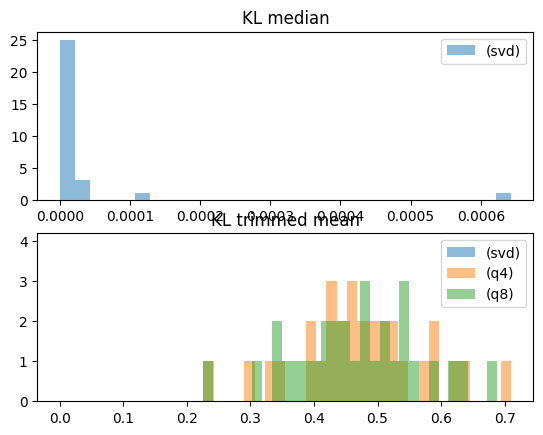

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2)

# one histogram per series, overlaid
ax[0].hist(kl_median_svd, bins=30, alpha=0.5, label="(svd)")
ax[0].hist(kl_median_q_4, bins=30, alpha=0.5, label="(q4)")
ax[0].hist(kl_median_q_8, bins=30, alpha=0.5, label="(q8)")
ax[0].set_title("KL median")
ax[0].legend()

ax[1].set_title("KL trimmed mean")
ax[1].hist(kl_trimmed_mean_svd, bins=30, alpha=0.5, label="(svd)")
ax[1].hist(kl_trimmed_mean_q_4, bins=30, alpha=0.5, label="(q4)")
ax[1].hist(kl_trimmed_mean_q_8, bins=30, alpha=0.5, label="(q8)")
ax[1].legend()

plt.show()

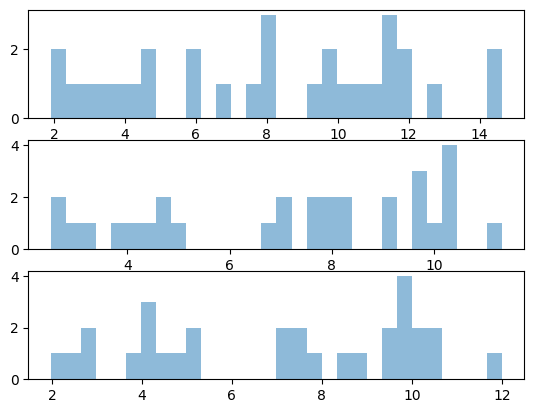

In [ ]:
kl_95th_svd = [np.percentile(t, 99) for t in kl_tensors_svd]
kl_95th_q_4 = [np.percentile(t, 99) for t in kl_tensors_q_4]
kl_95th_q_8 = [np.percentile(t, 99) for t in kl_tensors_q_8]

fig, ax = plt.subplots(3)

ax[0].hist(kl_95th_svd, bins=30, alpha=0.5, label="(svd)")
ax[1].hist(kl_95th_q_4, bins=30, alpha=0.5, label="(q4)")
ax[2].hist(kl_95th_q_8, bins=30, alpha=0.5, label="(q8)")
plt.show()

In [108]:
def spike_rate(kl_tensor, spike_threshold = 2):
    return np.sum(kl_tensor > spike_threshold) / len(kl_tensor)
print("svd", np.mean([spike_rate(k) for k in kl_tensors_svd]))
print("q4", np.mean([spike_rate(k) for k in kl_tensors_q_4]))
print("q8", np.mean([spike_rate(k) for k in kl_tensors_q_8]))


svd 0.06933333333333333
q4 0.07316666666666667
q8 0.06989583333333332


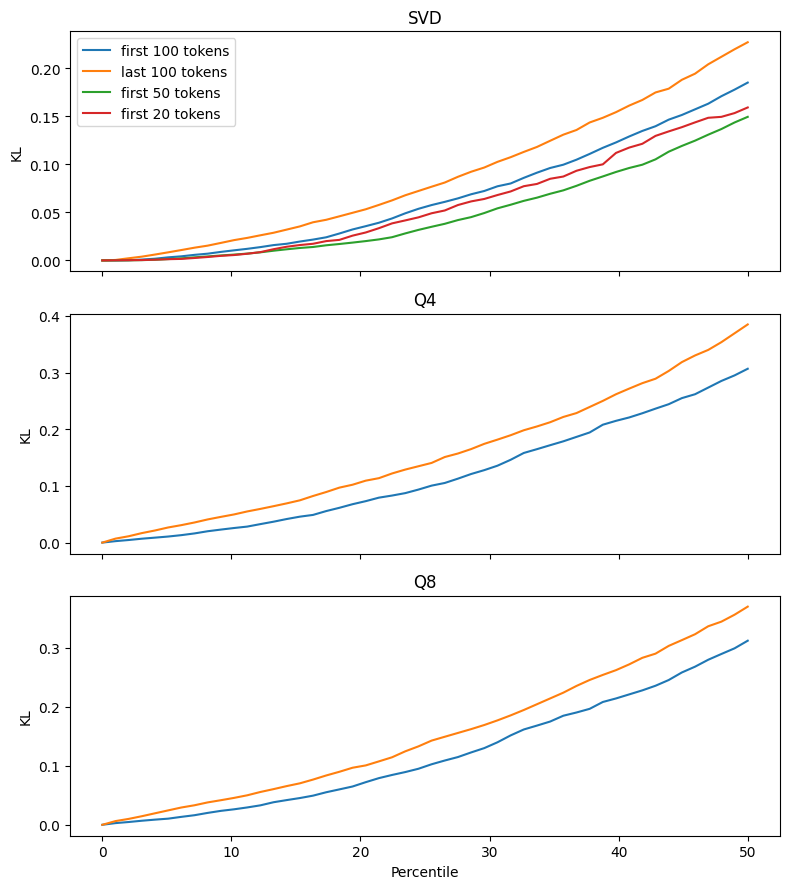

In [126]:
# plot percentile curves (handles ints, arrays, and tensors)
def _flatten_numeric(values):
    flat = []
    for v in values:
        if isinstance(v, torch.Tensor):
            flat.extend(v.detach().cpu().numpy().ravel().tolist())
        else:
            flat.extend(np.asarray(v).ravel().tolist())
    return np.asarray(flat, dtype=float)

cropped_kl_tensors_svd = [k[:100] for k in kl_tensors_svd]
cropped_kl_tensors_q_4 = [k[:100] for k in kl_tensors_q_4]
cropped_kl_tensors_q_8 = [k[:100] for k in kl_tensors_q_8]

end_kl_tensors_svd = [k[-100:] for k in kl_tensors_svd]
end_kl_tensors_q_4 = [k[-100:] for k in kl_tensors_q_4]
end_kl_tensors_q_8 = [k[-100:] for k in kl_tensors_q_8]\

tokens_50 = [k[:50] for k in kl_tensors_svd]
tokens_10 = [k[:20] for k in kl_tensors_svd]

percentiles = np.linspace(0, 50)
svd_vals = _flatten_numeric(cropped_kl_tensors_svd)
q4_vals = _flatten_numeric(cropped_kl_tensors_q_4)
q8_vals = _flatten_numeric(cropped_kl_tensors_q_8)

end_svd_vals = _flatten_numeric(end_kl_tensors_svd)
end_q4_vals = _flatten_numeric(end_kl_tensors_q_4)
end_q8_vals = _flatten_numeric(end_kl_tensors_q_8)

svd_50_vals = _flatten_numeric(tokens_50)
svd_10_vals = _flatten_numeric(tokens_10)

percentile_values = np.percentile(svd_vals, percentiles)
percentile_values_q_4 = np.percentile(q4_vals, percentiles)
percentile_values_q_8 = np.percentile(q8_vals, percentiles)

percentile_values_50 = np.percentile(svd_50_vals, percentiles)
percentile_values_10 = np.percentile(svd_10_vals, percentiles)

end_percentile_values = np.percentile(end_svd_vals, percentiles)
end_percentile_values_q_4 = np.percentile(end_q4_vals, percentiles)
end_percentile_values_q_8 = np.percentile(end_q8_vals, percentiles)

fig, ax = plt.subplots(3, figsize=(8, 9), sharex=True)
ax[0].plot(percentiles, percentile_values, label="first 100 tokens")
ax[0].plot(percentiles, end_percentile_values, label="last 100 tokens")
ax[0].plot(percentiles, percentile_values_50, label="first 50 tokens")
ax[0].plot(percentiles, percentile_values_10, label="first 20 tokens")
ax[0].set_title("SVD")
ax[0].legend()
ax[1].plot(percentiles, percentile_values_q_4)
ax[1].plot(percentiles, end_percentile_values_q_4)
ax[1].set_title("Q4")
ax[2].plot(percentiles, percentile_values_q_8)
ax[2].plot(percentiles, end_percentile_values_q_8)
ax[2].set_title("Q8")
ax[2].set_xlabel("Percentile")
for a in ax:
    a.set_ylabel("KL")

plt.tight_layout()
plt.show()

In [ ]:
###

In [16]:
### Layer By Layer analysis
import os

def load_layer_data(path: str):
    kl_tensors = []
    for file in os.listdir(path):
        if file.endswith(".pt") and "kl" in file:
            kl_stats = torch.load(os.path.join(path, file))
            kl_stats = kl_stats.float().cpu().numpy()
            kl_tensors.append(kl_stats)

    return kl_tensors


kl_by_layers = []
for folder in os.listdir("state_spectrum_sweep/experiments/suite_kl_layer_sweep_20260325_103013"):
    if os.path.isdir(os.path.join("state_spectrum_sweep/experiments/suite_kl_layer_sweep_20260325_103013", folder)):
        kl_by_layers.append(load_layer_data(os.path.join("state_spectrum_sweep/experiments/suite_kl_layer_sweep_20260325_103013", folder)))

In [14]:
average_kl_by_prompt = [[np.median(kl_by_layers[i][j]) for j in range(len(kl_by_layers[i]))] for i in range(len(kl_by_layers))]
average_kl_by_layer = [np.mean(prompt) for prompt in average_kl_by_prompt]

kl_95th_percentile_by_prompt = [[np.percentile(kl_by_layers[i][j], 99) for j in range(len(kl_by_layers[i]))] for i in range(len(kl_by_layers))]
kl_95th_percentile_by_layer = [np.mean(prompt) for prompt in kl_95th_percentile_by_prompt]

Text(0, 0.5, 'KL')

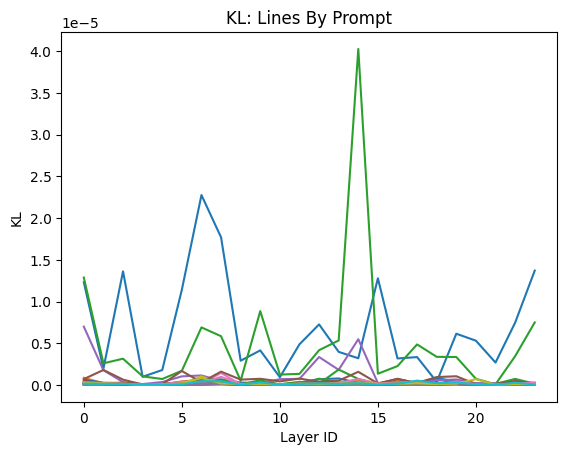

In [15]:
transposed_kl_by_layers = list(zip(*average_kl_by_prompt))

for i, lst in enumerate(transposed_kl_by_layers):
    plt.plot(lst, label=f'layer {i}')

plt.title("KL: Lines By Prompt")
plt.xlabel("Layer ID")
plt.ylabel("KL")

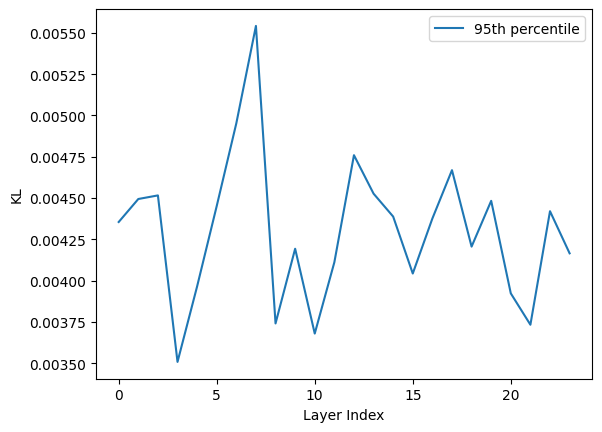

In [17]:
plt.plot(kl_95th_percentile_by_layer, label="95th percentile")
plt.xlabel("Layer Index")
plt.ylabel("KL")
plt.legend()

In [17]:
# each index is a prompt, containing a numpy array of length maximum 200.

kl_data = load_layer_data("state_spectrum_sweep/experiments/suite_kl_parallel_20260416_063354")
kl_q4 = load_layer_data("state_spectrum_sweep/experiments/suite_quant_20260328_4bit")
kl_q8 = load_layer_data("state_spectrum_sweep/experiments/suite_quant_20260328_8bit")

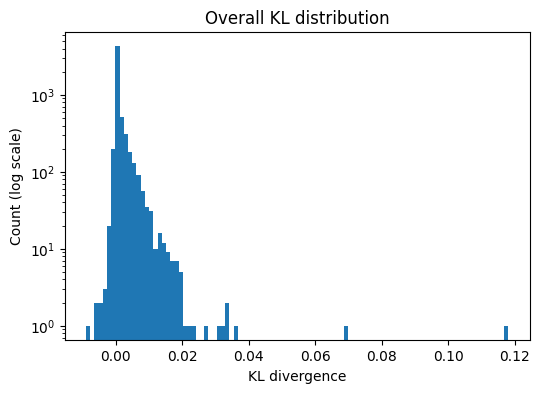

In [18]:
all_kl = np.concatenate(kl_data)
all_kl = all_kl[np.isfinite(all_kl)]  # drop inf/nan if needed
plt.figure(figsize=(6, 4))
plt.hist(all_kl, bins=100, log=True)
plt.xlabel("KL divergence")
plt.ylabel("Count (log scale)")
plt.title("Overall KL distribution")
plt.show()

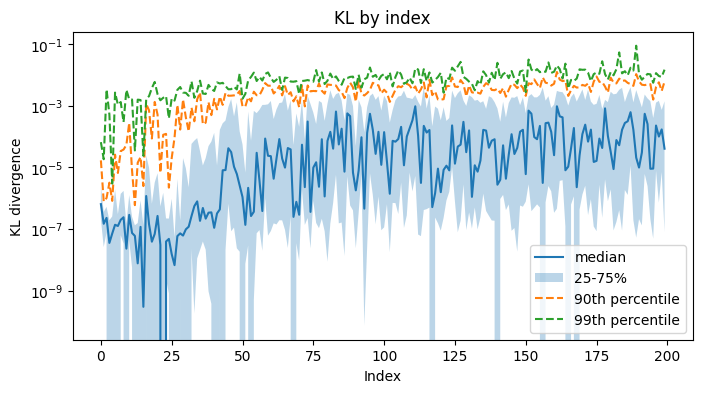

In [19]:
max_len = max(len(x) for x in kl_data)
arr = np.full((len(kl_data), max_len), np.nan)
for i, x in enumerate(kl_data):
    arr[i, :len(x)] = x
x = np.arange(max_len)
median = np.nanmedian(arr, axis=0)
p25 = np.nanpercentile(arr, 25, axis=0)
p75 = np.nanpercentile(arr, 75, axis=0)
p90 = np.nanpercentile(arr, 90, axis=0)
p99 = np.nanpercentile(arr, 99, axis=0)
plt.figure(figsize=(8, 4))
plt.plot(x, median, label="median")
plt.fill_between(x, p25, p75, alpha=0.3, label="25-75%")
plt.plot(x, p90, linestyle="--", label="90th percentile")
plt.plot(x, p99, linestyle="--", label="99th percentile")
plt.yscale("log")  # often very helpful for KL
plt.xlabel("Index")
plt.ylabel("KL divergence")
plt.title("KL by index")
plt.legend()
plt.show()

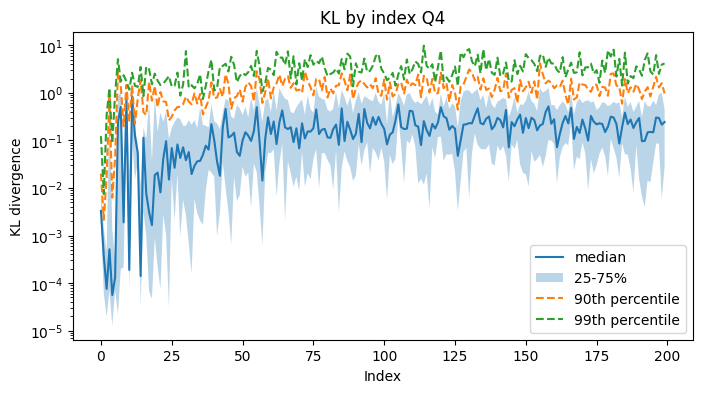

In [11]:
max_len = max(len(x) for x in kl_q4)
arr = np.full((len(kl_q4), max_len), np.nan)
for i, x in enumerate(kl_q4):
    arr[i, :len(x)] = x
x = np.arange(max_len)
median = np.nanmedian(arr, axis=0)
p25 = np.nanpercentile(arr, 25, axis=0)
p75 = np.nanpercentile(arr, 75, axis=0)
p90 = np.nanpercentile(arr, 90, axis=0)
p99 = np.nanpercentile(arr, 99, axis=0)
plt.figure(figsize=(8, 4))
plt.plot(x, median, label="median")
plt.fill_between(x, p25, p75, alpha=0.3, label="25-75%")
plt.plot(x, p90, linestyle="--", label="90th percentile")
plt.plot(x, p99, linestyle="--", label="99th percentile")
plt.yscale("log")  # often very helpful for KL
plt.xlabel("Index")
plt.ylabel("KL divergence")
plt.title("KL by index Q4")
plt.legend()
plt.show()

In [ ]:
max_len = max(len(x) for x in kl_q8)
arr = np.full((len(kl_q4), max_len), np.nan)
for i, x in enumerate(kl_q4):
    arr[i, :len(x)] = x
x = np.arange(max_len)
median = np.nanmedian(arr, axis=0)
p25 = np.nanpercentile(arr, 25, axis=0)
p75 = np.nanpercentile(arr, 75, axis=0)
p90 = np.nanpercentile(arr, 90, axis=0)
p99 = np.nanpercentile(arr, 99, axis=0)
plt.figure(figsize=(8, 4))
plt.plot(x, median, label="median")
plt.fill_between(x, p25, p75, alpha=0.3, label="25-75%")
plt.plot(x, p90, linestyle="--", label="90th percentile")
plt.plot(x, p99, linestyle="--", label="99th percentile")
plt.yscale("log")  # often very helpful for KL
plt.xlabel("Index")
plt.ylabel("KL divergence")
plt.title("KL by index")
plt.legend()
plt.show()

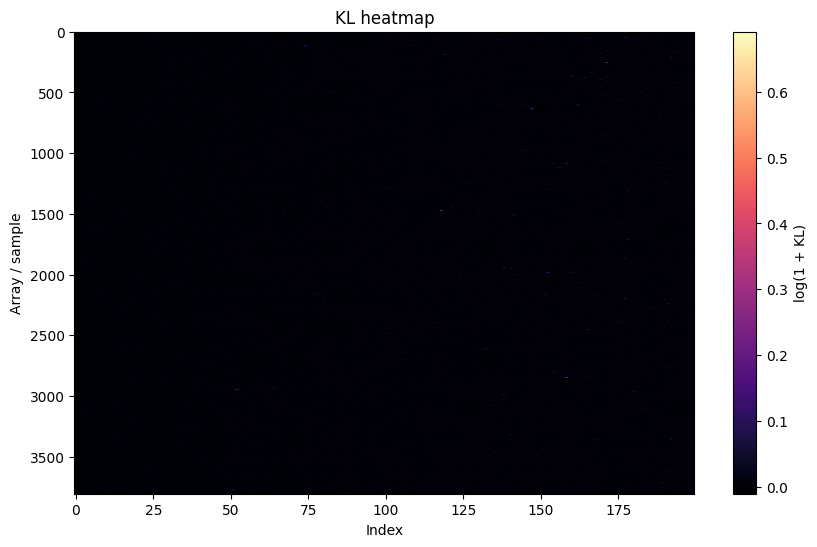

In [12]:
plt.figure(figsize=(10, 6))
plt.imshow(np.log1p(arr), aspect="auto", interpolation="nearest", cmap="magma")
plt.colorbar(label="log(1 + KL)")
plt.xlabel("Index")
plt.ylabel("Array / sample")
plt.title("KL heatmap")
plt.show()

In [42]:
import json

def load_metrics(path: str):
    metrics = []
    for file in os.listdir(path):
        if file.endswith(".json"):
            with open(os.path.join(path, file), "r") as f:
                metrics.append(json.load(f))
    return metrics

def load_rel_frob(path: str):
    rel_frob = []
    for file in os.listdir(path):
        if file.endswith(".pt") and "rel_frob" in file:
            rel_frob.append(torch.load(os.path.join(path, file)))
    return torch.cat(rel_frob)

def load_energy(path: str):
    energy = []
    for file in os.listdir(path):
        if file.endswith(".pt") and "energy" in file:
            energy.append(torch.load(os.path.join(path, file)))
    return torch.cat(energy)

def load_kl(path: str):
    kl = []
    for file in os.listdir(path):
        if file.endswith(".pt") and "kl" in file:
            kl.append(torch.load(os.path.join(path, file)))
    return torch.cat(kl)

metrics = load_metrics("state_spectrum_sweep/experiments/suite_kl_parallel_20260416_063354")

In [43]:
rel_frob = load_rel_frob("state_spectrum_sweep/experiments/suite_kl_parallel_20260416_063354")
energy = load_energy("state_spectrum_sweep/experiments/suite_kl_parallel_20260416_063354")
kl = load_kl("state_spectrum_sweep/experiments/suite_kl_parallel_20260416_063354")

In [47]:
#99th percentile value
rel_frob_np = rel_frob.numpy()
np.percentile(rel_frob_np, 99)
energy_np = energy.numpy()
print(np.percentile(energy_np, 1))
print(np.percentile(energy_np, 50))

kl_np = kl.to(torch.float32).numpy()
print(np.percentile(kl_np, 50))
print(np.percentile(kl_np, 99))


0.9670049
0.9969783
5.4091215e-06
0.013000488
